In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [4]:
attack_set = df[df["label"] != "BENIGN"]
attack_sample = (attack_set.groupby("label", group_keys=False).sample(n=2000, random_state=42, replace=True).reset_index(drop=True))

In [5]:
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=attack_sample.shape[0], replace=True, random_state=42)

In [6]:
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [7]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [9]:
model = XGBClassifier(
    n_estimators=300,   
    max_depth=6,
    learning_rate=0.03,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


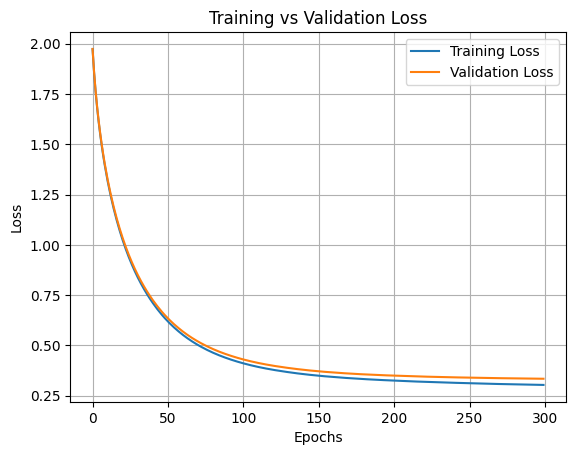

In [10]:
results = model.evals_result()

train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.8570833333333333
Weighted F1: 0.8537525166598353
Macro F1: 0.7229616354385421
ROC-AUC: 0.9945901096781306


In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=le.classes_))

               precision    recall  f1-score   support

       BENIGN       1.00      1.00      1.00      7200
    DrDoS_DNS       0.55      0.57      0.56       400
   DrDoS_LDAP       0.41      0.40      0.40       400
  DrDoS_MSSQL       0.61      0.63      0.62       400
    DrDoS_NTP       1.00      0.99      1.00       400
DrDoS_NetBIOS       0.87      0.71      0.78       400
   DrDoS_SNMP       0.47      0.54      0.50       400
   DrDoS_SSDP       0.54      0.42      0.47       400
    DrDoS_UDP       0.47      0.43      0.45       400
         LDAP       0.57      0.52      0.54       400
        MSSQL       0.62      0.64      0.63       400
      NetBIOS       0.87      0.79      0.83       400
      Portmap       0.82      0.98      0.89       400
          Syn       1.00      0.99      1.00       400
         TFTP       1.00      1.00      1.00       400
          UDP       0.44      0.27      0.34       400
      UDP-lag       0.59      0.98      0.74       400
       UD

In [13]:
ae_df = pd.read_csv("adversarial_epsilon_0.01.csv")

In [14]:
ae_df.head()

,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_duration_ms,src2dst_packets,src2dst_bytes,dst2src_duration_ms,dst2src_packets,dst2src_bytes,bidirectional_min_ps,...,udps.dns_port_count,udps.srcdst_dns_port_src_count,udps.dns_port_src_count,udps.srcdst_vul_ports_count,udps.src2dst_packet_count,udps.bidirectional_packet_count,udps.srcdst_src2dst_packet_count,udps.srcdst_bidirectional_packet_count,true_label,y_pred
0,2554,2,4446,2554,3,65841,5992,113,213309,579,...,0,0,0,0,1320,1320,1320,1320,2,2
1,447,4,5242,447,3,65841,41803,113,4416,1122,...,0,0,0,1,712,732,712,732,1,2
2,447,4,814,447,3,5647,5992,5,4416,1122,...,0,0,0,0,537,537,537,537,1,1
3,447,4,814,447,3,5647,5992,5,4416,579,...,0,0,0,0,700,700,700,700,2,1
4,447,4,814,447,3,5647,5992,5,4416,579,...,0,0,0,0,700,700,700,700,2,1


In [18]:
ae_X = ae_df.drop(columns=["true_label","y_pred"], errors="ignore").select_dtypes(include=[np.number])
ae_X.replace([np.inf, -np.inf], np.nan, inplace=True)
ae_X.fillna(0, inplace=True)
ae_y = ae_df["true_label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
ae_X = ae_X.astype("float32")

In [23]:
ae_pred = model.predict(ae_X)
ae_prob = model.predict_proba(ae_X)
print("Accuracy:", accuracy_score(ae_y, ae_pred))
print("Weighted F1:", f1_score(ae_y, ae_pred, average='weighted'))
print("Macro F1:", f1_score(ae_y, ae_pred, average='macro'))
# print("ROC-AUC:", roc_auc_score(ae_y, ae_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.33284444444444444
Weighted F1: 0.34564033031355545
Macro F1: 0.054574788996877184
